# Healthcare Patient Outcome Analysis

**Name:** Rona Zhang  
**Date:** 05/13/2026

## Introduction

Healthcare systems are increasingly leveraging data-driven approaches to improve patient outcomes, reduce costs, and enhance operational efficiency. Electronic Health Records (EHR) provide comprehensive information on patient demographics, clinical conditions, treatments, and outcomes, enabling deeper analysis of healthcare processes and decision-making.

This report aims to explore the characteristics of patient outcomes using a synthetic healthcare dataset. Specifically, it investigates factors associated with hospital readmissions, variations in treatment costs, and differences across patient risk profiles and clinical conditions. By analyzing both patient-level features and outcome data, the report seeks to identify meaningful patterns that can inform healthcare strategies.

By applying statistical analysis, simulation techniques, and machine learning methods such as A/B testing, bootstrapping, principal component analysis (PCA), and clustering, this study provides insights into how patient characteristics relate to outcomes. The findings aim to support better risk stratification, resource allocation, and data-driven decision-making in healthcare settings.

# 1. Data Overview and Initial Screening

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the two datasets 
patients = pd.read_csv('patients.csv')
outcomes = pd.read_csv('patient_outcome.csv')

In [3]:
patients.head()

,patient_id,age,gender,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,smoking_status,alcohol_use,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0000001,66,M,23.5,148,81,64,98.4,former,light,...,0,0,1,0,0,0,0,0,1,0
1,P0000002,75,M,24.8,158,86,45,99.5,never,moderate,...,0,0,0,0,1,0,0,0,1,0
2,P0000003,82,M,17.8,135,57,90,98.2,never,light,...,0,0,1,0,0,0,0,0,0,0
3,P0000004,73,F,28.1,118,83,102,98.9,former,moderate,...,0,0,0,0,0,0,0,0,0,0
4,P0000005,86,F,30.6,156,81,56,98.7,never,heavy,...,0,0,0,0,1,1,0,1,0,0


In [181]:
outcomes.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd
0,P0061265,2018-02-25,2018-02-27,2,0,0,0,home,0,NaN,470,12069.89
1,P0098996,2023-06-07,2023-06-08,1,0,0,0,skilled_nursing,0,NaN,292,14687.35
2,P0046588,2018-08-13,2018-08-22,9,0,0,0,home,0,NaN,470,2065.34
3,P0058572,2022-06-11,2022-06-13,2,0,0,0,home_health,0,NaN,293,9888.26
4,P0080733,2021-05-23,2021-05-25,2,0,0,0,skilled_nursing,0,NaN,291,15078.42


### Check dataset sizes

In [182]:
# Check the shape of each dataset
print("Patients dataset shape:", patients.shape)
print("Outcome dataset shape:", outcomes.shape)

Patients dataset shape: (100000, 28)
Outcome dataset shape: (6820, 12)


### Check data structure and types

In [183]:
print("Patients dataset info:")
patients.info()

print("\nOutcome dataset info:")
outcomes.info()

Patients dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   patient_id                  100000 non-null  object 
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   bmi                         100000 non-null  float64
 4   systolic_bp                 100000 non-null  int64  
 5   diastolic_bp                100000 non-null  int64  
 6   heart_rate                  100000 non-null  int64  
 7   temperature_f               100000 non-null  float64
 8   smoking_status              100000 non-null  object 
 9   alcohol_use                 100000 non-null  object 
 10  exercise_level              100000 non-null  object 
 11  insurance_type              100000 non-null  object 
 12  charlson_index              100000 non-null  int64

### Summary statistics

In [184]:
print("Patients summary statistics:")
patients.describe().T

Patients summary statistics:


,count,mean,std,min,25%,50%,75%,max
age,100000.0,71.634330,17.292069,19.0,59.0,73.0,86.0,95.0
bmi,100000.0,27.513744,5.403874,16.0,23.8,27.5,31.2,51.4
systolic_bp,100000.0,133.648960,19.253868,80.0,121.0,134.0,147.0,220.0
diastolic_bp,100000.0,84.391660,12.472988,50.0,76.0,84.0,93.0,130.0
heart_rate,100000.0,72.023400,11.887678,45.0,64.0,72.0,80.0,124.0
temperature_f,100000.0,98.603557,0.500259,96.3,98.3,98.6,98.9,100.6
charlson_index,100000.0,0.814480,1.026106,0.0,0.0,0.0,2.0,7.0
dx_hypertension,100000.0,0.676850,0.467682,0.0,0.0,1.0,1.0,1.0
dx_type2_diabetes,100000.0,0.157500,0.364273,0.0,0.0,0.0,0.0,1.0
dx_hyperlipidemia,100000.0,0.545340,0.497943,0.0,0.0,1.0,1.0,1.0


In [185]:
print("\nOutcome summary statistics:")
outcomes.describe().T


Outcome summary statistics:


,count,mean,std,min,25%,50%,75%,max
length_of_stay_days,6820.0,5.240616,4.320870,1.0,2.00,4.000,7.00,30.00
icu_admission,6820.0,0.022287,0.147627,0.0,0.00,0.000,0.00,1.00
icu_days,6820.0,0.077566,0.576711,0.0,0.00,0.000,0.00,6.00
in_hospital_death,6820.0,0.014663,0.120208,0.0,0.00,0.000,0.00,1.00
readmitted_30d,6820.0,0.147507,0.354637,0.0,0.00,0.000,0.00,1.00
days_to_readmission,1006.0,14.898608,8.354917,1.0,8.00,15.000,22.00,29.00
primary_drg,6820.0,317.422581,82.729904,194.0,291.00,292.000,392.00,470.00
total_charges_usd,6820.0,18357.596952,17080.289862,2000.0,7954.45,13264.295,22507.67,173082.48


### Check missing values

In [186]:
print("Missing values in patients dataset:")
print(patients.isna().sum())
print("Total missing values in patients dataset:", patients.isna().sum().sum())

print("\nMissing values in outcome dataset:")
print(outcomes.isna().sum())
print("Total missing values in outcome dataset:", outcomes.isna().sum().sum())

Missing values in patients dataset:
patient_id                    0
age                           0
gender                        0
bmi                           0
systolic_bp                   0
diastolic_bp                  0
heart_rate                    0
temperature_f                 0
smoking_status                0
alcohol_use                   0
exercise_level                0
insurance_type                0
charlson_index                0
dx_hypertension               0
dx_type2_diabetes             0
dx_hyperlipidemia             0
dx_obesity                    0
dx_coronary_artery_disease    0
dx_heart_failure              0
dx_atrial_fibrillation        0
dx_chronic_kidney_disease     0
dx_copd                       0
dx_asthma                     0
dx_depression                 0
dx_anxiety                    0
dx_hypothyroidism             0
dx_osteoarthritis             0
dx_type1_diabetes             0
dtype: int64
Total missing values in patients dataset: 0

Missing va

In [187]:
# Rows with missing values in outcome dataset
missing_rows = outcomes[outcomes.isna().any(axis=1)]
missing_rows

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,primary_drg,total_charges_usd
0,P0061265,2018-02-25,2018-02-27,2,0,0,0,home,0,NaN,470,12069.89
1,P0098996,2023-06-07,2023-06-08,1,0,0,0,skilled_nursing,0,NaN,292,14687.35
2,P0046588,2018-08-13,2018-08-22,9,0,0,0,home,0,NaN,470,2065.34
3,P0058572,2022-06-11,2022-06-13,2,0,0,0,home_health,0,NaN,293,9888.26
4,P0080733,2021-05-23,2021-05-25,2,0,0,0,skilled_nursing,0,NaN,291,15078.42
...,...,...,...,...,...,...,...,...,...,...,...,...
6814,P0015518,2023-12-14,2023-12-21,7,0,0,0,home_health,0,NaN,292,6497.47
6815,P0063464,2024-04-10,2024-04-12,2,0,0,0,home,0,NaN,392,21618.37
6816,P0082708,2018-09-26,2018-10-01,5,0,0,0,home,0,NaN,392,9081.07
6817,P0004798,2018-03-11,2018-03-12,1,0,0,0,home,0,NaN,291,19880.46


### Duplicate checks

In [188]:
# Check duplicate rows
print("Duplicate rows in patients:", patients.duplicated().sum())
print("Duplicate rows in outcome:", outcomes.duplicated().sum())

# Check duplicate patient IDs
print("Duplicate patient_id in patients:", patients.duplicated(subset='patient_id').sum())
print("Duplicate patient_id in outcome:", outcomes.duplicated(subset='patient_id').sum())

Duplicate rows in patients: 0
Duplicate rows in outcome: 0
Duplicate patient_id in patients: 0
Duplicate patient_id in outcome: 0


### Categorical variables overview

In [189]:
# Inspect categorical variables in patients dataset
cat_cols_patients = ['gender', 'smoking_status', 'alcohol_use', 'exercise_level', 'insurance_type']

for col in cat_cols_patients:
    print()
    print(patients[col].value_counts())


gender
F    50703
M    49297
Name: count, dtype: int64

smoking_status
never      56100
former     25105
current    18795
Name: count, dtype: int64

alcohol_use
light       37121
none        32933
moderate    22999
heavy        6947
Name: count, dtype: int64

exercise_level
light        34979
moderate     30016
sedentary    25054
vigorous      9951
Name: count, dtype: int64

insurance_type
commercial    48723
medicaid      19057
medicare      18053
uninsured      9112
tricare        5055
Name: count, dtype: int64


In [190]:
# Inspect categorical variables in outcome dataset
cat_cols_outcomes = ['discharge_disposition', 'primary_drg']

for col in cat_cols_outcomes:
    print()
    print(outcomes[col].value_counts())


discharge_disposition
home               3706
home_health        1330
skilled_nursing     837
rehab               661
hospice             186
expired             100
Name: count, dtype: int64

primary_drg
292    1422
291    1373
194    1037
392    1013
293     997
470     978
Name: count, dtype: int64


**Note:** The variable `primary_drg` here is stored as an integer in the dataset. However, it represents diagnosis-related group categories rather than continuous numerical values. Therefore, it should be treated as a categorical variable in the analysis.

### Outlier check

#### boxplots of patients

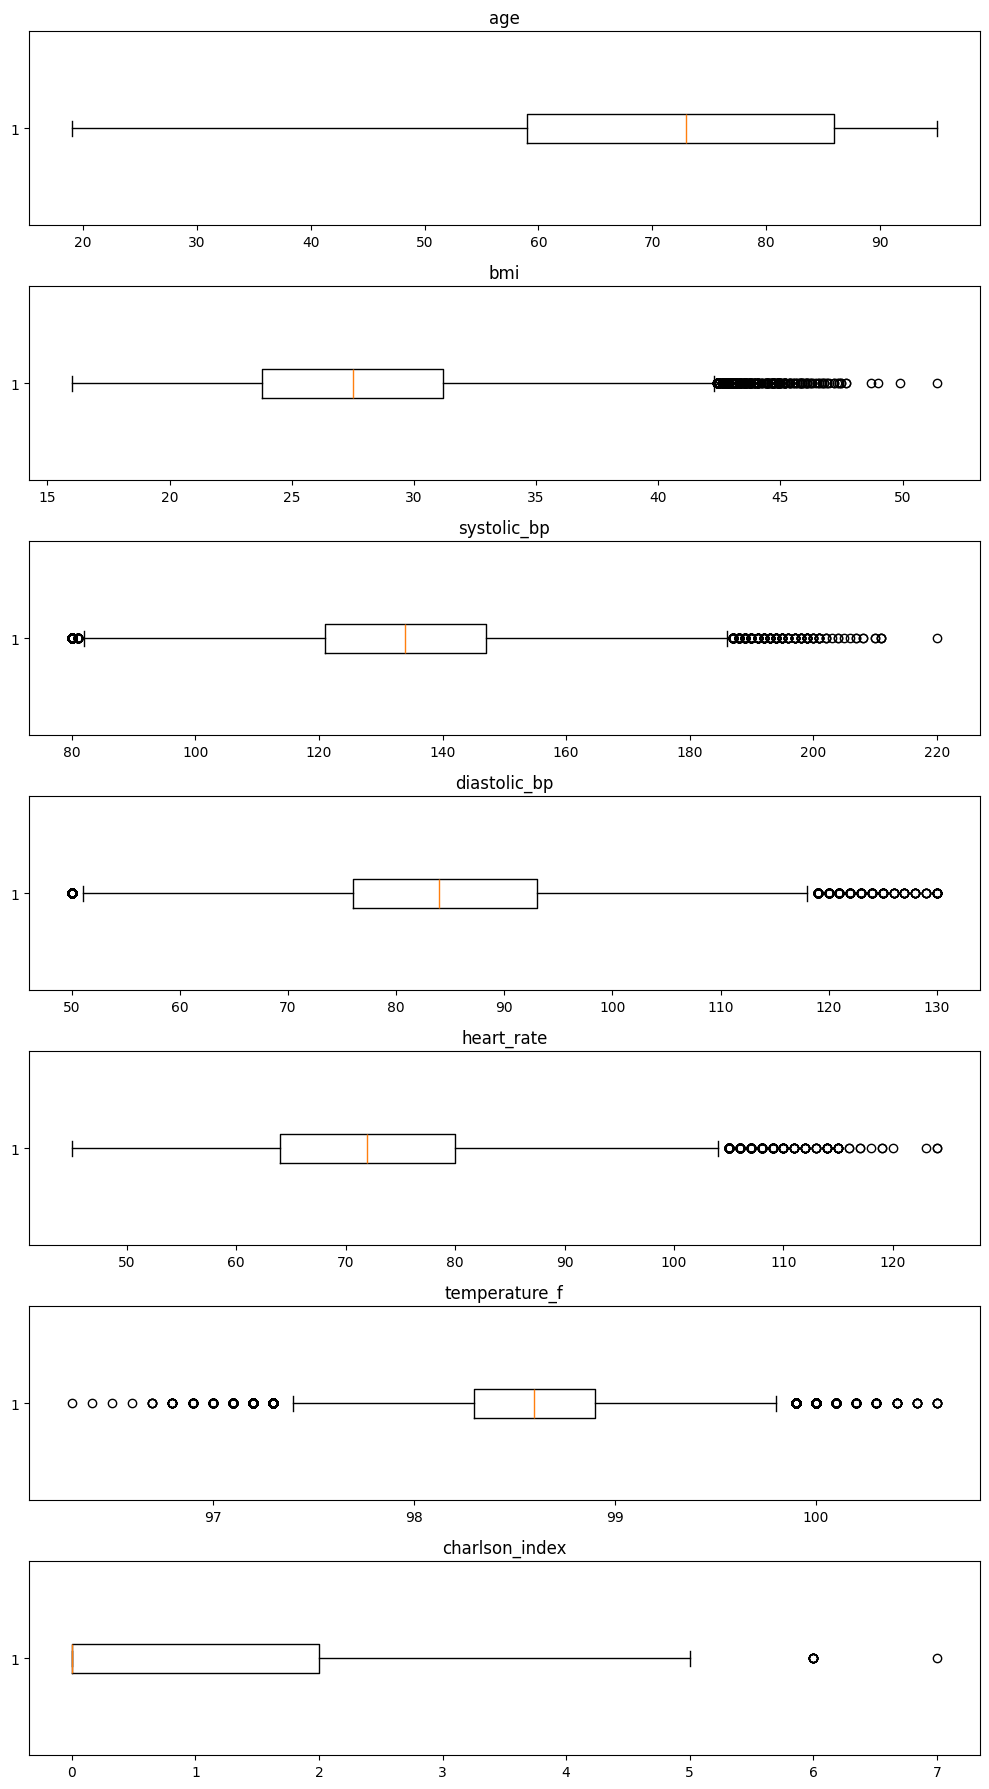

In [191]:
# Boxplots for patient numeric variables
num_cols_patients = [
    'age', 'bmi', 'systolic_bp', 'diastolic_bp',
    'heart_rate', 'temperature_f', 'charlson_index'
]

fig, axes = plt.subplots(len(num_cols_patients), 1, figsize=(10, 18))

for i, col in enumerate(num_cols_patients):
    axes[i].boxplot(patients[col].dropna(), vert=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

#### boxplots of outcomes

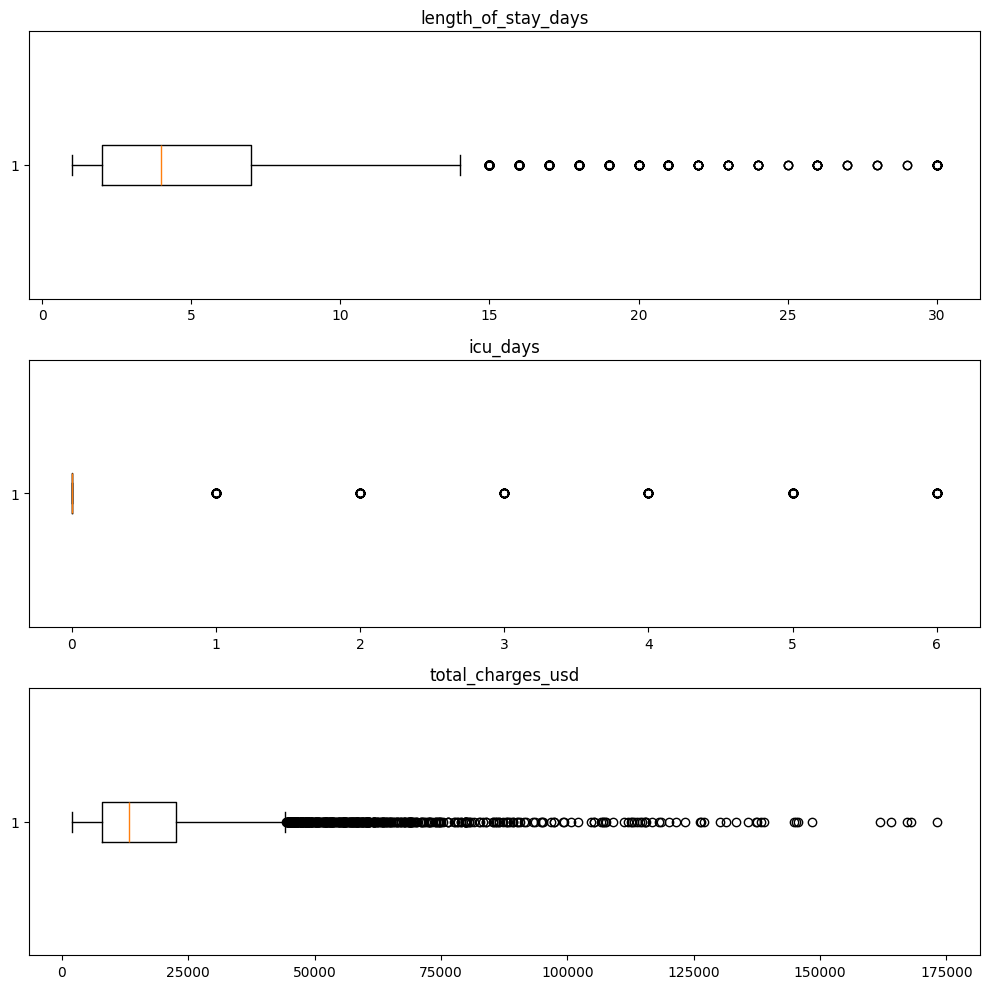

In [192]:
# Boxplots for outcome numeric variables
num_cols_outcomes = [
    'length_of_stay_days', 'icu_days', 'total_charges_usd'
]

fig, axes = plt.subplots(len(num_cols_outcomes), 1, figsize=(10, 10))

for i, col in enumerate(num_cols_outcomes):
    axes[i].boxplot(outcomes[col].dropna(), vert=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

### Check invalid date order

In [193]:
# Convert date columns to datetime format
outcomes_clean = outcomes.copy()
outcomes_clean['admission_date'] = pd.to_datetime(outcomes_clean['admission_date'])
outcomes_clean['discharge_date'] = pd.to_datetime(outcomes_clean['discharge_date'])

# Check if discharge date is earlier than admission date
invalid_dates = outcomes_clean[outcomes_clean['discharge_date'] < outcomes_clean['admission_date']]

print("Number of invalid date records:", invalid_dates.shape[0])

Number of invalid date records: 0


### Check length of stay consistency

In [194]:
# Compare calculated and recorded length_of_stay_days
los_mismatch = outcomes_clean[outcomes_clean['length_of_stay_days'] != ((outcomes_clean['discharge_date'] - outcomes_clean['admission_date']).dt.days)]

print("Number of LOS mismatches:", los_mismatch.shape[0])

Number of LOS mismatches: 0


### Check date range

In [195]:
# Check min and max dates
print("Admission date range:",
      outcomes_clean['admission_date'].min(),
      "to",
      outcomes_clean['admission_date'].max())

print("Discharge date range:",
      outcomes_clean['discharge_date'].min(),
      "to",
      outcomes_clean['discharge_date'].max())

Admission date range: 2018-01-01 00:00:00 to 2024-12-30 00:00:00
Discharge date range: 2018-01-03 00:00:00 to 2025-01-08 00:00:00


### Check unrealistic values

In [196]:
print("Age range:", patients['age'].min(), "-", patients['age'].max())
print("BMI range:", patients['bmi'].min(), "-", patients['bmi'].max())
print("Systolic BP range:", patients['systolic_bp'].min(), "-", patients['systolic_bp'].max())
print("Temperature range:", patients['temperature_f'].min(), "-", patients['temperature_f'].max())

Age range: 19 - 95
BMI range: 16.0 - 51.4
Systolic BP range: 80 - 220
Temperature range: 96.3 - 100.6


### Findings

The datasets are clean, consistent, and suitable for further analysis. The patients dataset contains complete records with no missing values, and the outcome dataset only exhibits missing values in the variable `days_to_readmission`. These missing values are structurally expected, since they correspond to patients who were not readmitted within 30 days, and therefore do not represent data quality issues actually.

No duplicate records were identified in either dataset, and all variables appear to have appropriate data types after converting date into datetime format. Additional data quality checks confirm that discharge dates consistently occur after admission dates, and that the recorded length of stay aligns perfectly with the calculated values from the date variables, indicating strong internal consistency.

Descriptive statistics and range checks show that key variables such as age, BMI, blood pressure, and temperature all fall within clinically plausible ranges. Although several continuous variables like total charges, length of stay, and vital signs may exhibit right-skewed distributions with apparent outliers, these values are reasonable in a healthcare context and likely reflect real-world variability rather than any data errors.

So overall, no major data quality concerns are identified. The datasets demonstrate strong integrity and can be reliably used for subsequent analyses, with appropriate handling of structurally missing variables.

# 2. Feature Engineering

### Merge the two datasets

In [197]:
# Merge patient-level characteristics with hospitalization outcomes
df = outcomes_clean.merge(patients, on='patient_id', how='left')
df.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,...,dx_heart_failure,dx_atrial_fibrillation,dx_chronic_kidney_disease,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes
0,P0061265,2018-02-25,2018-02-27,2,0,0,0,home,0,NaN,...,0,0,1,0,0,0,0,0,0,0
1,P0098996,2023-06-07,2023-06-08,1,0,0,0,skilled_nursing,0,NaN,...,0,0,0,0,0,0,0,0,1,0
2,P0046588,2018-08-13,2018-08-22,9,0,0,0,home,0,NaN,...,0,0,0,0,1,0,0,1,0,0
3,P0058572,2022-06-11,2022-06-13,2,0,0,0,home_health,0,NaN,...,0,0,1,0,0,0,1,0,0,0
4,P0080733,2021-05-23,2021-05-25,2,0,0,0,skilled_nursing,0,NaN,...,0,0,1,1,0,0,0,0,0,0


### Create clinically meaningful features

To improve interpretability and support subsequent analysis, several new features should be engineered based on domain knowledge and clinical relevance.

- Continuous variables such as age and BMI will be transformed into categorical variables. Grouping age into life-stage categories allows for easier comparison across different patient populations, and BMI categories follow standard clinical cutoffs to make the results more interpretable in a healthcare context.

- The Charlson index, which is commonly used as a representation for patient health risk, will be converted into a binary indicator. Patients with a Charlson index of 3 or higher are classified as high-risk. This transformation simplifies the variable and facilitates group-based comparisons in later analyses such as A/B testing or clustering.

In [198]:
df_updated = df.copy()

# Create age groups to capture life-stage differences
df_updated['age_group'] = pd.cut(
    df_updated['age'],
    bins=[0, 39, 59, 74, 120],
    labels=['<40', '40-59', '60-74', '75+']
)

# Create BMI categories using standard clinical cutoffs
df_updated['bmi_category'] = pd.cut(
    df_updated['bmi'],
    bins=[0, 18.5, 25, 30, 100],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese']
)

# Create a high-risk indicator based on Charlson index
df_updated['high_charlson'] = (df_updated['charlson_index'] >= 3).astype(int)

df_updated.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,discharge_disposition,readmitted_30d,days_to_readmission,...,dx_copd,dx_asthma,dx_depression,dx_anxiety,dx_hypothyroidism,dx_osteoarthritis,dx_type1_diabetes,age_group,bmi_category,high_charlson
0,P0061265,2018-02-25,2018-02-27,2,0,0,0,home,0,NaN,...,0,0,0,0,0,0,0,75+,Overweight,1
1,P0098996,2023-06-07,2023-06-08,1,0,0,0,skilled_nursing,0,NaN,...,0,0,0,0,0,1,0,75+,Underweight,0
2,P0046588,2018-08-13,2018-08-22,9,0,0,0,home,0,NaN,...,0,1,0,0,1,0,0,75+,Obese,0
3,P0058572,2022-06-11,2022-06-13,2,0,0,0,home_health,0,NaN,...,0,0,0,1,0,0,0,75+,Overweight,1
4,P0080733,2021-05-23,2021-05-25,2,0,0,0,skilled_nursing,0,NaN,...,1,0,0,0,0,0,0,75+,Obese,1


### Binary encoding for gender

The variable `gender` contains only two categories and is therefore treated as a binary categorical variable. Instead of applying one-hot encoding, it should be converted into a single binary numeric variable. This approach avoids creating redundant features while preserving interpretability. The resulting variable directly indicates whether a patient is male or female and is suitable for subsequent analysis.

In [199]:
# Convert binary categorical variable gender into numeric form
# M = 1, F = 0
df_updated['gender'] = (df_updated['gender'] == 'M').astype(int)
df_updated[['gender']].head()

,gender
0,1
1,0
2,1
3,0
4,0


### One-hot encode multi-category variables

Categorical variables with multiple levels here will be transformed into numeric representations using one-hot encoding, converting each category into a separate 0/1 indicator column. We choose this approach because it can avoid creating a false numeric orders and allow each category to be represented independently. In addition, it produces a fully numeric dataset that is compatible with subsequent analytical methods such as PCA or clustering.

In [200]:
# Convert multi-category variables into numeric form using one-hot encoding
categorical_cols = [
    'smoking_status',
    'alcohol_use',
    'exercise_level',
    'insurance_type',
    'discharge_disposition',
    'age_group',
    'bmi_category'
]

df_encoded = pd.get_dummies(df_updated, columns=categorical_cols, drop_first=True)
bool_cols = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
df_encoded.head()

,patient_id,admission_date,discharge_date,length_of_stay_days,icu_admission,icu_days,in_hospital_death,readmitted_30d,days_to_readmission,primary_drg,...,discharge_disposition_home_health,discharge_disposition_hospice,discharge_disposition_rehab,discharge_disposition_skilled_nursing,age_group_40-59,age_group_60-74,age_group_75+,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,P0061265,2018-02-25,2018-02-27,2,0,0,0,0,NaN,470,...,0,0,0,0,0,0,1,0,1,0
1,P0098996,2023-06-07,2023-06-08,1,0,0,0,0,NaN,292,...,0,0,0,1,0,0,1,0,0,0
2,P0046588,2018-08-13,2018-08-22,9,0,0,0,0,NaN,470,...,0,0,0,0,0,0,1,0,0,1
3,P0058572,2022-06-11,2022-06-13,2,0,0,0,0,NaN,293,...,1,0,0,0,0,0,1,0,1,0
4,P0080733,2021-05-23,2021-05-25,2,0,0,0,0,NaN,291,...,0,0,0,1,0,0,1,0,0,1


#3. Modeling

## A/B Testing

### Charlson index Risk and 30-Day Readmission

We will examine whether patients with higher health risk measured by the Charlson index have higher 30-day readmission rates compared to lower-risk patients. This is meaningful in a healthcare context because patients with higher health risk are generally more vulnerable and may require more follow-up care.

- **Null Hypothesis (H0)**: The 30-day readmission rate is the same for high-risk patients (Charlson index ≥ 3) and low-risk patients (Charlson index < 3).
- **Alternative Hypothesis (H1)**: The readmission rate for high-risk patients is higher than that for low-risk patients.

In [201]:
from statsmodels.stats.proportion import proportions_ztest

# Select readmission outcomes for each group
high_risk_readmit = df_updated[df_updated['high_charlson'] == 1]['readmitted_30d']
low_risk_readmit = df_updated[df_updated['high_charlson'] == 0]['readmitted_30d']

# Calculate number of readmissions
n_success_high = high_risk_readmit.sum()
n_success_low = low_risk_readmit.sum()

# Calculate number of observations
n_obs_high = len(high_risk_readmit)
n_obs_low = len(low_risk_readmit)

# Perform two-sample z-test for proportions (one-sided)
# H0: p_high = p_low
# H1: p_high > p_low

successes = np.array([n_success_high, n_success_low])
nobs = np.array([n_obs_high, n_obs_low])
print(successes)
print(nobs)

z_stat, p_value = proportions_ztest(successes, nobs, alternative='larger')

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

[255 751]
[1164 5656]
Z-statistic: 7.5607
P-value: 0.0000


Since the p-value is close to 0 and the z-statistic is large, the results show that the 30-day readmission rate for high-risk patients is significantly higher than that for low-risk patients. Therefore, we reject the null hypothesis.

This suggests that high-risk patients are more likely to be readmitted within 30 days, indicating a need for more targeted follow-up care.

### Readmission and Length of Stay

Next, we will examine whether patients who are readmitted within 30 days have longer average hospital stays compared to those who are not readmitted. This is meaningful because longer hospital stays may reflect greater severity or more complex care.

- **Null Hypothesis (H0)**: The average length of stay is the same for readmitted and non-readmitted patients.

- **Alternative Hypothesis (H1)**: The average length of stay for readmitted patients is higher than that for non-readmitted patients.

In [202]:
from scipy import stats

# Select length of stay for each group
readmit_los = df_updated[df_updated['readmitted_30d'] == 1]['length_of_stay_days']
no_readmit_los = df_updated[df_updated['readmitted_30d'] == 0]['length_of_stay_days']

# Perform independent samples t-test (one-tailed)
# H0: mu_readmit = mu_no_readmit
# H1: mu_readmit > mu_no_readmit
t_stat, p_value = stats.ttest_ind(readmit_los, no_readmit_los, equal_var=False, alternative='greater')

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 0.7283
P-value: 0.2333


Since the p-value is greater than 0.05 and the t-statistic is small, the average length of stay for readmitted patients is not significantly higher than that for non-readmitted patients. Therefore, we fail to reject the null hypothesis.

This suggests that there is no strong evidence that readmitted patients have longer hospital stays compared to non-readmitted patients. In other words, length of stay alone may not be a key factor associated with readmission risk in this case.

### Subgroup Analysis: Older vs Younger Patients

To further examine the potential impact of confounding factors, we will perform subgroup analysis based on age. Patients are divided into older (age ≥ 75) and younger groups.

This allows us to assess whether the relationship between the health risk and readmission remains consistent across different age groups.

#### Older Patients (Age ≥ 75)

- **Null Hypothesis (H0)**: The 30-day readmission rate is the same for high-risk and low-risk patients among older patients.
- **Alternative Hypothesis (H1)**: The 30-day readmission rate for high-risk patients is higher than that for low-risk patients among older patients.

In [203]:
# Subgroup: older patients (age ≥ 75)
old_group = df_updated[df_updated['age_group'] == '75+']

# Select readmission outcomes for each group
old_high = old_group[old_group['high_charlson'] == 1]['readmitted_30d']
old_low = old_group[old_group['high_charlson'] == 0]['readmitted_30d']

# Calculate number of readmissions
n_success_old_high = old_high.sum()
n_success_old_low = old_low.sum()

# Calculate number of observations
n_obs_old_high = len(old_high)
n_obs_old_low = len(old_low)

# Perform two-sample z-test for proportions (one-sided)
# H0: p_high = p_low
# H1: p_high > p_low

successes_old = np.array([n_success_old_high, n_success_old_low])
nobs_old = np.array([n_obs_old_high, n_obs_old_low])
print(successes_old)
print(nobs_old)

z_stat_old, p_value_old = proportions_ztest(successes_old, nobs_old, alternative='larger')

print(f"Z-statistic: {z_stat_old:.4f}")
print(f"P-value: {p_value_old:.4f}")

[190 516]
[ 832 3588]
Z-statistic: 5.9980
P-value: 0.0000


The results show that the 30-day readmission rate for high-risk patients is significantly higher than that for low-risk patients among older patients since p-value < 0.05. This suggests that the relationship between health risk and readmission persists within the older population.

#### Younger Patients (Age < 75)

- **Null Hypothesis (H0)**: The 30-day readmission rate is the same for high-risk and low-risk patients among younger patients.
- **Alternative Hypothesis (H1)**: The 30-day readmission rate for high-risk patients is higher than that for low-risk patients among younger patients.

In [204]:
# Subgroup: younger patients (age < 75)
young_group = df_updated[df_updated['age_group'] != '75+']

# Select readmission outcomes for each group
young_high = young_group[young_group['high_charlson'] == 1]['readmitted_30d']
young_low = young_group[young_group['high_charlson'] == 0]['readmitted_30d']

# Calculate number of readmissions
n_success_young_high = young_high.sum()
n_success_young_low = young_low.sum()

# Calculate number of observations
n_obs_young_high = len(young_high)
n_obs_young_low = len(young_low)

# Perform two-sample z-test for proportions (one-sided)
# H0: p_high = p_low
# H1: p_high > p_low

successes_young = np.array([n_success_young_high, n_success_young_low])
nobs_young = np.array([n_obs_young_high, n_obs_young_low])
print(successes_young)
print(nobs_young)

z_stat_young, p_value_young = proportions_ztest(successes_young, nobs_young, alternative='larger')

print(f"Z-statistic: {z_stat_young:.4f}")
print(f"P-value: {p_value_young:.4f}")

[ 65 235]
[ 332 2068]
Z-statistic: 4.2012
P-value: 0.0000


Again, the results still show that the 30-day readmission rate for high-risk patients is significantly higher than that for low-risk patients among younger patients with p-value close to 0. This indicates that the observed relationship is also present among younger patients.

## Simulation

### Bootstrap Estimation of Readmission Rate

We will use bootstrapping to estimate the variability and uncertainty of the 30-day readmission rate. This metric is important because readmission rate is a key indicator of patient risk and healthcare performance.

By repeatedly resampling the data, we can build a bootstrap distribution of the readmission rate and use it to construct a confidence interval.

In [205]:
# number of bootstrap samples
sims = 5000

# initialize random generator
rng = np.random.default_rng(seed = 4034)

# initialize outcome array with each item to be the readmission rate of one bootstrap sample
boot_outcome = np.empty(sims)

# extract readmission variable
readmit_array = df_updated['readmitted_30d']

# create bootstrap samples
for n in range(sims):
    sample = rng.choice(readmit_array, size = len(readmit_array), replace = True)
    boot_outcome[n] = sample.mean()

# print bootstrap mean
print(boot_outcome.mean())

# 95% CI
print(np.percentile(boot_outcome, [2.5, 97.5]))

0.1474781818181818
[0.13929619 0.15601173]


The bootstrap results estimate the 30-day readmission rate to be approximately 0.147, with a 95% confidence interval of [0.139, 0.156]. This relatively narrow interval suggests that the estimate is stable and that the true readmission rate is likely to fall within this range.

### Bootstrap Estimation of Difference in Mean Charges between High-risk and Low-risk Patients

We can also use bootstrapping to estimate the difference in average hospitalization charges between high-risk and low-risk patients defined by the Charlson index.

This is meaningful because higher-risk patients may require more complex care and greater healthcare resource utilization, which may be reflected in higher hospitalization charges.

In [206]:
def bootstrap_diff_means_ci(df, group, value, g1, g2, n_boot=5000, ci=0.95, random_state=4034):
    rng = np.random.default_rng(random_state)

    x = df.loc[df[group] == g1, value].to_numpy()
    y = df.loc[df[group] == g2, value].to_numpy()

    obs_diff = y.mean() - x.mean()
    boot_diffs = np.empty(n_boot)

    for i in range(n_boot):
        x_boot = rng.choice(x, size=len(x), replace=True)
        y_boot = rng.choice(y, size=len(y), replace=True)
        boot_diffs[i] = y_boot.mean() - x_boot.mean()

    alpha = 1 - ci
    lower = np.percentile(boot_diffs, 100 * alpha / 2)
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    return obs_diff, (lower, upper), boot_diffs

In [207]:
obs, ci, diffs = bootstrap_diff_means_ci(
    df_updated,
    'high_charlson',
    'total_charges_usd',
    0,
    1,
    n_boot=5000,
    ci=0.95,
    random_state=4034
)

print("Observed difference (high - low):", obs)
print("95% CI:", ci)

Observed difference (high - low): 658.8585785736177
95% CI: (np.float64(-486.43451039008744), np.float64(1804.1042886391374))


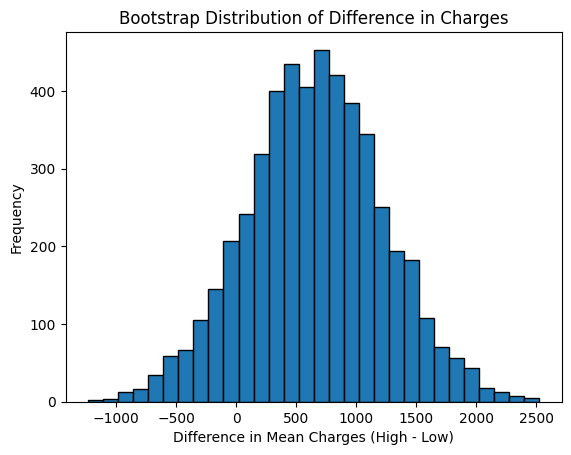

In [208]:
plt.hist(diffs, bins=30, edgecolor='black')
plt.title('Bootstrap Distribution of Difference in Charges')
plt.xlabel('Difference in Mean Charges (High - Low)')
plt.ylabel('Frequency')
plt.show()

The bootstrap estimate of the difference in mean hospitalization charges between high-risk and low-risk patients is approximately 659. However, the 95% confidence interval [-486, 1804] includes 0, indicating that the difference is not statistically significant. This suggests that although high-risk patients tend to have higher average charges, there is no strong evidence that the difference is systematic and it may be driven by variability in the data.

## Principal Component Analysis (PCA)

We will apply PCA to the numeric clinical and utilization variables in the dataset to identify groups of correlated features that may be consolidated into a smaller number of components. This can help reduce dimensionality while preserving as much information as possible.

Before applying PCA, the selected variables will be standardized, since PCA is sensitive to scale. We will also use the KMO test and Bartlett's test to assess whether PCA is appropriate for this dataset.

In [209]:
# Select numeric variables for PCA
metric = [
    'age',
    'bmi',
    'systolic_bp',
    'diastolic_bp',
    'heart_rate',
    'temperature_f',
    'charlson_index',
    'length_of_stay_days',
    'icu_days',
    'total_charges_usd'
]

X = df_updated[metric]
X.head()

,age,bmi,systolic_bp,diastolic_bp,heart_rate,temperature_f,charlson_index,length_of_stay_days,icu_days,total_charges_usd
0,76,25.2,139,94,67,99.1,3,2,0,12069.89
1,88,18.4,157,109,63,99.3,0,1,0,14687.35
2,88,31.7,147,92,77,99.3,0,9,0,2065.34
3,95,27.6,167,68,55,98.8,3,2,0,9888.26
4,78,36.9,132,88,61,98.4,3,2,0,15078.42


In [210]:
from sklearn.preprocessing import StandardScaler

# Standardize the selected variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### KMO and Bartlett's Test

In [211]:
! pip install factor_analyzer

In [212]:
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity

# Perform KMO test
kmo_all_vars, kmo_overall = calculate_kmo(X_scaled)
print(f'KMO overall: {kmo_overall:.4f}')
print(f'KMO per variable: {kmo_all_vars}')

# Perform Bartlett's test of sphericity
chi_square_value, p_value = calculate_bartlett_sphericity(X_scaled)
print(f"Bartlett's Test of Sphericity: Chi-square value = {chi_square_value:.2f}, p-value = {p_value:.4f}")

KMO overall: 0.5346
KMO per variable: [0.52377564 0.48214676 0.53835903 0.55427174 0.50339775 0.50454773
 0.57921237 0.49494319 0.51327609 0.57345221]
Bartlett's Test of Sphericity: Chi-square value = 1231.22, p-value = 0.0000


The KMO overall measure is 0.5346, which is slightly below the commonly recommended threshold of 0.6. This suggests that the shared variance among variables is moderate and that the dataset may not have a very strong underlying factor structure.

However, Bartlett's test is highly significant with p-value close to 0, indicating that the variables are correlated and suitable for PCA actually.

So overall, while the KMO result suggests moderate adequacy, the significant Bartlett's test supports the application of PCA for exploratory dimensionality reduction in this analysis.

### Generate PCA

In [213]:
from sklearn.decomposition import PCA

# Perform PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Eigenvalues
eigenvalues = pca.explained_variance_
print('Eigenvalues (Explained Variance) per Principal Component:')
print(eigenvalues)

# Explained variance ratio
explained_ratio = pca.explained_variance_ratio_
print('\nExplained variance ratio:')
print(explained_ratio)

# Cumulative explained variance
cumsum_variance = np.cumsum(explained_ratio)
print('\nCumulative explained variance:')
print(cumsum_variance)

# Number of components with eigenvalue > 1
print("\nNumber of components with eigenvalue > 1:", sum(eigenvalues > 1))

# Component where cumulative variance exceeds 65%
print("Principal component where cumulative variance exceeds 65%:",
      np.argmax(cumsum_variance >= 0.65) + 1)

Eigenvalues (Explained Variance) per Principal Component:
[1.46076827 1.0578244  1.03622733 1.01807009 0.99294296 0.9810689
 0.96225069 0.94723965 0.91140433 0.63366986]

Explained variance ratio:
[0.14605541 0.10576693 0.10360754 0.10179208 0.09927974 0.0980925
 0.09621096 0.09471008 0.09112707 0.06335769]

Cumulative explained variance:
[0.14605541 0.25182234 0.35542988 0.45722196 0.5565017  0.6545942
 0.75080516 0.84551524 0.93664231 1.        ]

Number of components with eigenvalue > 1: 4
Principal component where cumulative variance exceeds 65%: 6


### Selecting the Number of Principal Components

To determine the number of principal components to retain, we can use the scree plot and cumulative explained variance. The scree plot helps identify an “elbow point” where additional components provide diminishing returns in explained variance. We can also consider Kaiser's criterion, which suggests retaining components with eigenvalues greater than 1.

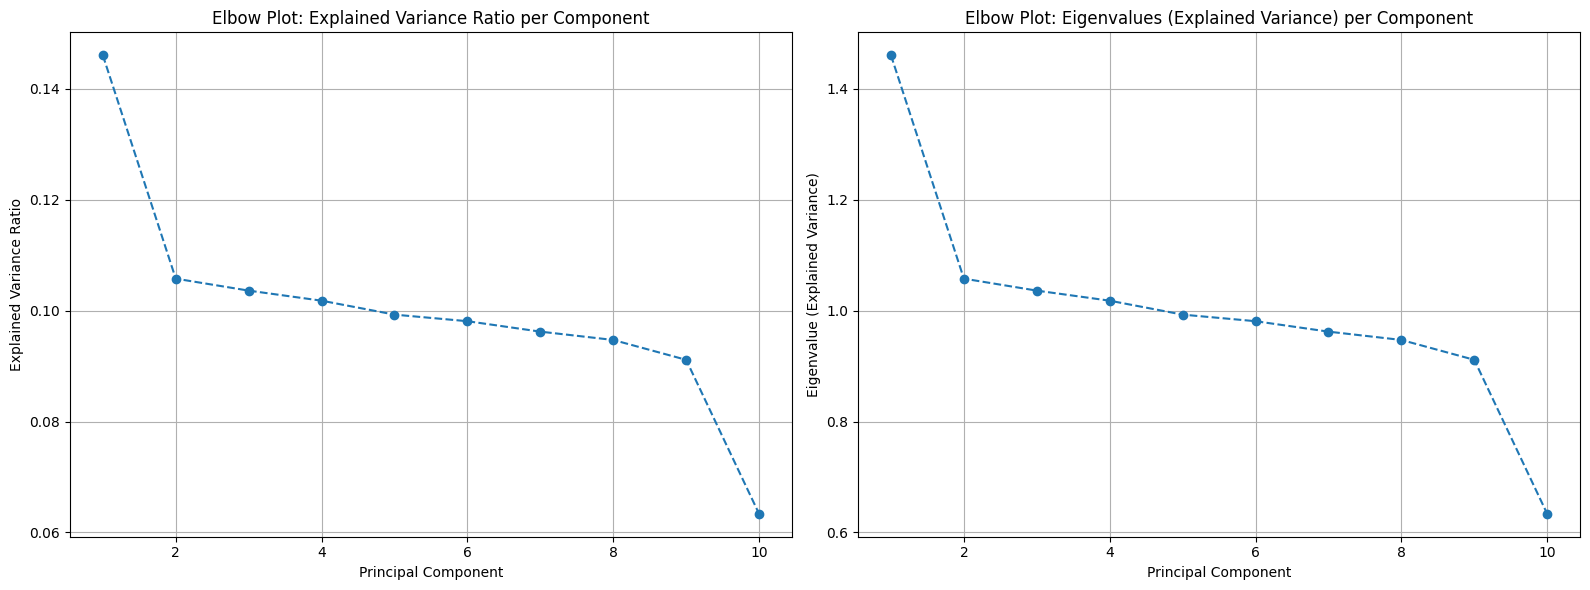

In [214]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow plot for explained variance ratio
axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1),
             pca.explained_variance_ratio_,
             marker='o', linestyle='--')
axes[0].set_title('Elbow Plot: Explained Variance Ratio per Component')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].grid(True)

# Elbow plot for eigenvalues
axes[1].plot(range(1, len(pca.explained_variance_) + 1),
             pca.explained_variance_,
             marker='o', linestyle='--')
axes[1].set_title('Elbow Plot: Eigenvalues (Explained Variance) per Component')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Eigenvalue (Explained Variance)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Based on Kaiser's criterion, four principal components have eigenvalues greater than 1, indicating that they explain more variance than individual standardized variables. And although the scree plot does not show a clear elbow point and six components are needed to exceed 65% cumulative variance, retaining four components provides a reasonable balance between capturing sufficient variability and maintaining interpretability. Therefore, we retain the first four principal components for our analysis.

### PCA interpretation

In [215]:
pca = PCA(n_components=4)
pca.fit(X_scaled)

loadings = pd.DataFrame(
    pca.components_,
    columns=metric,
    index=[f'PC{i+1}' for i in range(4)]
)

print(loadings)

          age       bmi  systolic_bp  diastolic_bp  heart_rate  temperature_f  \
PC1  0.662443 -0.007391     0.549576      0.469334    0.019115       0.056375   
PC2 -0.005290  0.426724    -0.094493     -0.094582    0.130789      -0.159121   
PC3  0.004669  0.514540     0.041304     -0.016492    0.641209       0.328492   
PC4  0.014358 -0.098269    -0.001567     -0.157753    0.220697      -0.431402   

     charlson_index  length_of_stay_days  icu_days  total_charges_usd  
PC1        0.163605             0.023800  0.054698           0.070278  
PC2        0.523870            -0.195849  0.658108          -0.108052  
PC3       -0.160641             0.317716 -0.192475          -0.224495  
PC4        0.187919             0.638184  0.021121           0.536093  


The PC1 is primarily driven by age, systolic blood pressure, and diastolic blood pressure, with all variables contributing positively. This suggests that PC1 captures overall patient baseline characteristics, particularly age and blood pressure-related health status.

The PC2 is strongly associated with BMI, Charlson index, and ICU days, indicating that it reflects patient severity and health burden. The positive loadings on these variables suggest that higher values of PC2 correspond to patients with greater health risk and more intensive care needs.

The PC3 is mainly influenced by heart rate, BMI, and temperature, suggesting that it captures physiological conditions and vital signs variability.

The PC4 is largely driven by length of stay and total hospitalization charges, indicating that it reflects healthcare utilization and cost-related factors.

Overall, these components capture different dimensions of patient health and healthcare resource usage, including baseline characteristics, clinical severity, physiological conditions, and utilization intensity.

## Clustering

### Variable Selection and Method

To segment patients into meaningful groups, we will use the first four principal components together with a small number of clinically interpretable variables. The principal components summarize the main variation in the continuous clinical and utilization variables, including age, BMI, vital signs, health burden, length of stay, ICU use, and hospitalization charges. This helps reduce dimensionality while preserving the most important information.

In addition, we will also include a few binary variables such as gender and ICU admission to retain clinically meaningful differences that may help improve interpretability. We exclude patient id and dates variables because they are not appropriate clustering features.

K-means is chosen here because it is a standard unsupervised method for partitioning observations into compact patient segments.

In [216]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use PCA scores plus a small number of interpretable binary variables
df_cluster = pd.DataFrame(
    X_pca[:, :4],
    columns=['PCA1', 'PCA2', 'PCA3', 'PCA4']
)

# Add selected interpretable variables
df_cluster['gender'] = df_updated['gender'].reset_index(drop=True)
df_cluster['icu_admission'] = df_updated['icu_admission'].reset_index(drop=True)

# Check the clustering dataframe
print(df_cluster.head())
print(df_cluster.info())

       PCA1      PCA2      PCA3      PCA4  gender  icu_admission
0  0.548118  0.366831 -0.525043 -1.005608       1              0
1  1.783243 -1.809994 -0.923008 -1.863144       0              0
2  0.841918 -0.712805  1.852033 -0.839453       1              0
3  1.163557  0.581346 -1.017799 -0.734820       0              0
4  0.109479  1.505456 -0.254054 -0.546762       0              0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6820 entries, 0 to 6819
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PCA1           6820 non-null   float64
 1   PCA2           6820 non-null   float64
 2   PCA3           6820 non-null   float64
 3   PCA4           6820 non-null   float64
 4   gender         6820 non-null   int64  
 5   icu_admission  6820 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 319.8 KB
None


### Selecting the Number of Clusters

We will use the silhouette score to evaluate different values of k. This allows us to choose the number of clusters that best balances cohesion within clusters and separation between clusters. The clustering variables will be standardized before applying k-means so that each variable contributes fairly to the distance calculation.

In [217]:
# Standardize the clustering data
scaler_kmeans = StandardScaler()
X_cluster_scaled = scaler_kmeans.fit_transform(df_cluster)

# Try a range of k values
k_range = range(3, 11)
random_seed = 4034

print('k-means clustering')
print('------------------------------------------------------------------')

results = []
kmeans_models = {}

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init=100)
    kmeans.fit(X_cluster_scaled)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_cluster_scaled, labels)
    print(f"  For {k}, the average silhouette score is: {silhouette_avg:.4f}")

    results.append({'k': k, 'silhouette_score': silhouette_avg})
    kmeans_models[k] = kmeans

# Find the best k based on silhouette score
best = max(results, key=lambda x: x['silhouette_score'])

print("\nHighest silhouette score:", round(best['silhouette_score'], 4))
print("Best k:", best['k'])

k-means clustering
------------------------------------------------------------------
  For 3, the average silhouette score is: 0.2519
  For 4, the average silhouette score is: 0.2426
  For 5, the average silhouette score is: 0.2258
  For 6, the average silhouette score is: 0.2000
  For 7, the average silhouette score is: 0.1893
  For 8, the average silhouette score is: 0.1967
  For 9, the average silhouette score is: 0.2011
  For 10, the average silhouette score is: 0.1940

Highest silhouette score: 0.2519
Best k: 3


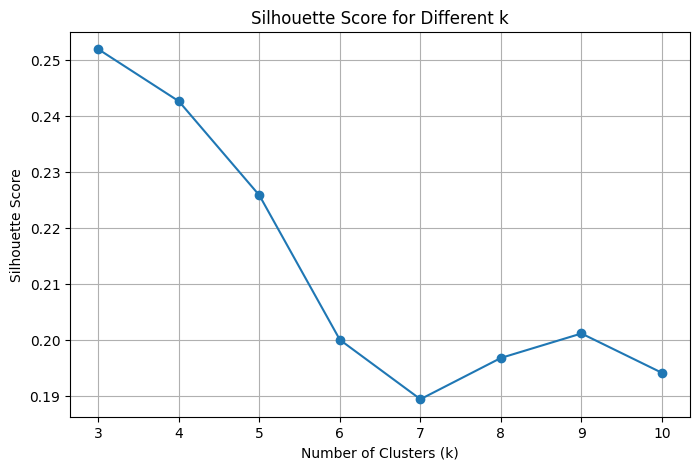

In [218]:
results_df = pd.DataFrame(results)

# Plot silhouette scores
plt.figure(figsize=(8,5))
plt.plot(results_df['k'], results_df['silhouette_score'], marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.grid(True)
plt.show()

A higher silhouette score indicates better separation between clusters and more cohesive grouping within clusters. From the results and the plot above, the highest silhouette score is achieved at k = 3, suggesting that three clusters provide the most appropriate segmentation for this dataset.

### Final Clustering

We then fit the final k-means model based on k=3 and assign each patient to a cluster. To understand the characteristics of each segment, we will compare key variables such as patient risk, ICU usage, length of stay, hospitalization charges, and readmission rates across clusters. This will allow us to identify meaningful patient groups and assess their clinical and operational differences.

In [219]:
# final clustering with best k
kmeans = KMeans(n_clusters=3, random_state=random_seed, n_init=100)
kmeans.fit(X_cluster_scaled)

# obtain cluster assignments
labels = kmeans.labels_

# attach cluster labels
df_cluster['cluster'] = labels

# combine cluster labels with key original variables for interpretation
other_metric = ['gender', 'icu_admission', 'cluster']

df_cluster_final = pd.concat(
    [df_cluster[other_metric],
     df_updated[['age', 'bmi', 'charlson_index', 'length_of_stay_days',
                 'total_charges_usd', 'readmitted_30d']].reset_index(drop=True)],
    axis=1
)

# cluster summary
df_cluster_final.groupby('cluster').mean()

,gender,icu_admission,age,bmi,charlson_index,length_of_stay_days,total_charges_usd,readmitted_30d
cluster,,,,,,,,
0,1.000000,0.0,77.453015,27.550597,1.333639,5.273646,18401.366122,0.148148
1,0.000000,0.0,77.665981,27.566892,1.339606,5.229638,18296.428365,0.142017
2,0.453947,1.0,80.019737,27.744079,1.796053,4.776316,18785.494868,0.256579


The clustering analysis identifies three patient segments based on principal components and selected clinical indicators. Overall, differences across clusters are relatively modest, suggesting that the dataset does not exhibit strong natural groupings, which is consistent with the PCA results.

However, cluster 2 shows slightly higher Charlson index values and higher readmission rates, indicating a relatively higher-risk group that may benefit from closer monitoring and targeted follow-up care. The remaining clusters have similar profiles in terms of age, BMI, and healthcare utilization.

From a healthcare perspective, these segments can still provide useful insights for identifying higher-risk patients and guiding interventions. At the same time, the limited separation may also suggest that more variables may be needed to achieve clearer patient segmentation.

### Clustering Without PCA

To further explore whether clearer patient segmentation can be achieved, we can perform clustering directly on selected clinical and utilization variables without applying PCA. This approach preserves the original structure of key variables, which may provide stronger differentiation between patient groups.

In [220]:
# Select variables directly (no PCA)
df_cluster_raw = df_updated[[
    'charlson_index',
    'icu_admission',
    'length_of_stay_days',
    'total_charges_usd'
]].copy()

scaler = StandardScaler()
X_raw_scaled = scaler.fit_transform(df_cluster_raw)

# Find the optimal k
k_range = range(3, 11)
random_seed = 4034

results = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_seed, n_init=100)
    kmeans.fit(X_raw_scaled)
    labels = kmeans.labels_

    silhouette_avg = silhouette_score(X_raw_scaled, labels)
    print(f"For {k}, silhouette score: {silhouette_avg:.4f}")

    results.append({'k': k, 'silhouette_score': silhouette_avg})

# best k
best = max(results, key=lambda x: x['silhouette_score'])

print("\nBest k:", best['k'])

For 3, silhouette score: 0.3195
For 4, silhouette score: 0.3530
For 5, silhouette score: 0.3855
For 6, silhouette score: 0.3801
For 7, silhouette score: 0.3608
For 8, silhouette score: 0.3362
For 9, silhouette score: 0.3422
For 10, silhouette score: 0.3344

Best k: 5


In [221]:
best_k = best['k']

kmeans = KMeans(n_clusters=best_k, random_state=random_seed, n_init=100)
kmeans.fit(X_raw_scaled)

labels = kmeans.labels_

# attach cluster label
df_cluster_final = df_updated.copy()
df_cluster_final['cluster'] = labels

# select same variables as before
cluster_vars = [
    'age',
    'bmi',
    'charlson_index',
    'icu_admission',
    'length_of_stay_days',
    'total_charges_usd',
    'readmitted_30d',
    'gender'
]

df_cluster_final.groupby('cluster')[cluster_vars].mean()

,age,bmi,charlson_index,icu_admission,length_of_stay_days,total_charges_usd,readmitted_30d,gender
cluster,,,,,,,,
0,78.253350,27.675152,2.485993,0.0,4.043443,14622.975778,0.191636,0.492083
1,76.792326,27.495995,0.417368,0.0,4.039044,14295.690875,0.106698,0.484685
2,78.076816,27.554609,1.251397,0.0,14.758380,16022.459274,0.146648,0.502793
3,80.019737,27.744079,1.796053,1.0,4.776316,18785.494868,0.256579,0.453947
4,77.972973,27.372973,1.262548,0.0,4.805019,62514.378803,0.140927,0.492278


The clustering analysis based on key clinical and utilization variables identifies five distinct patient segments with clearer differences compared to the PCA-based approach before.

Cluster 1 represents a low-risk group, with the lowest Charlson index and the lowest readmission rate. These patients also have relatively low hospitalization costs and short lengths of stay, suggesting a generally healthier population.

Cluster 0 and Cluster 3 represent higher-risk groups. Cluster 0 shows the highest health burden, while Cluster 3 is characterized by ICU admission and the highest readmission rate. These segments indicate patients with greater clinical severity who may require closer monitoring and more intensive care.

Cluster 2 stands out due to its significantly longer length of stay, suggesting prolonged hospitalization and potentially more complex treatment needs, even though its readmission rate is moderate.

Cluster 4 is distinguished by extremely high hospitalization costs, despite having moderate clinical risk levels. This suggests a group of patients with high resource utilization, which may be driven by specific treatments.

Overall, this clustering approach provides more meaningful segmentation, clearly distinguishing low-risk, high-risk, high-utilization, and high-cost patient groups.

# Conclusion

This analysis applies a combination of A/B testing, simulation, PCA, and clustering to understand patient risk and healthcare utilization. The results show that higher Charlson index is significantly associated with higher readmission rates, while length of stay alone is not a strong predictor. Bootstrap simulation confirms that the overall readmission rate is stable, while differences in hospitalization charges across risk groups are not statistically significant.

To move beyond individual variables, PCA is used to capture the underlying structure of clinical and utilization variables, summarizing them into key dimensions such as baseline health, severity, and resource use. Clustering is then applied to identify patient segments. While PCA-based clustering provides a structured view of the data, clustering directly on key clinical and utilization variables produces clearer and more interpretable segments.

From a healthcare perspective, these findings help identify high-risk patients who may benefit from targeted interventions such as enhanced follow-up care, while high-cost segments highlight opportunities to improve resource allocation and operational efficiency. Overall, this integrated approach shows that PCA is useful for understanding data structure, while clustering is more effective for identifying actionable patient groups, enabling more informed and data-driven healthcare decision-making.